# Module Metrics
Load canonical evaluation methods for grid scales, orientations, and module grouping.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.evaluation import (
    module_index_by_sorted_score,
    get_grid_scales_cm,
    get_grid_orientations_deg,
    summarize_by_module,
    plot_sac_examples_with_scale_orientation,
)


## Impact of having both separate inf lrs and blockwise Wr

In [ ]:
from scipy.stats import mannwhitneyu, kruskal
runs_dt = [
    "Apr-19-2026-13-52-23",  # both: diff inf_lr + block wr
    "Apr-11-2026-20-05-03",  # diff inf_lr only
    "Apr-12-2026-09-50-39",  # block wr only
]

n_cells = 64
cell_rows = []
run_stats = []

def p_to_stars(p):
    if not np.isfinite(p): return "n/a"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return "ns"

for dt in runs_dt:
    path = f'../results/tpc/{dt}'
    mod_idx, cfg = module_index_by_sorted_score(path, n_cells=n_cells)

    # use env height from config for cm conversion
    h = float(cfg.get("box_height", 1.6))
    scales_cm, scales_px, *_ = get_grid_scales_cm(dt, model='tpc', n_cells=n_cells)
    print(scales_px.max(), scales_px.min(), scales_px.mean())

    valid = np.isfinite(scales_cm)
    scales = scales_cm[valid]
    mods = mod_idx[valid]

    inf_lr = cfg.get("inf_lr", [])
    inf_lr_u = np.unique(np.asarray(inf_lr, dtype=float)) if isinstance(inf_lr, list) else np.array([inf_lr], dtype=float)
    diff_inf = len(inf_lr_u) > 1
    block_wr = bool(cfg.get("wr_block_diag", False))

    if diff_inf and block_wr: condition = "diff_inf + block_wr"
    elif diff_inf and (not block_wr): condition = "diff_inf only"
    elif (not diff_inf) and block_wr: condition = "block_wr only"
    else: condition = "neither"

    for s, m in zip(scales, mods):
        cell_rows.append({
            "run": dt,
            "module": int(m),
            "scale_cm": float(s),
            "condition": condition,
            "block_wr": block_wr,
            "diff_inf": diff_inf
        })

    groups = [scales[mods == m] for m in sorted(np.unique(mods))]
    groups = [g for g in groups if len(g) > 1]

    if len(groups) == 2:
        test = "Mann-Whitney U"
        stat, p = mannwhitneyu(groups[0], groups[1], alternative="two-sided")
    elif len(groups) > 2:
        test = "Kruskal-Wallis"
        stat, p = kruskal(*groups)
    else:
        test, stat, p = "NA", np.nan, np.nan

    run_stats.append({
        "run": dt, "condition": condition, "test": test, "stat": stat, "p": p, "sig": p_to_stars(p)
    })

cell_df = pd.DataFrame(cell_rows)
stats_df = pd.DataFrame(run_stats).sort_values("run")
summary_df = (
    cell_df.groupby(["run", "condition", "module"], as_index=False)["scale_cm"]
    .agg(mean="mean", std="std", n="count")
)

display(stats_df)
display(summary_df.head(10))

11.325336920276678 6.669263149016708 8.184586027788683
10.545619687260624 7.275625218930629 8.306434285010312
10.72063439780482 6.599582456545028 8.063487987107916


,run,condition,test,stat,p,sig
1,Apr-11-2026-20-05-03,diff_inf only,Mann-Whitney U,336.5,0.023773,*
2,Apr-12-2026-09-50-39,block_wr only,Mann-Whitney U,314.5,0.139313,ns
0,Apr-19-2026-13-52-23,diff_inf + block_wr,Mann-Whitney U,276.5,0.001602,**


,run,condition,module,mean,std,n
0,Apr-11-2026-20-05-03,diff_inf only,0,64.897589,3.958415,28
1,Apr-11-2026-20-05-03,diff_inf only,1,67.660052,5.130225,36
2,Apr-12-2026-09-50-39,block_wr only,0,63.482354,6.185680,46
3,Apr-12-2026-09-50-39,block_wr only,1,67.128754,7.605725,18
4,Apr-19-2026-13-52-23,diff_inf + block_wr,0,62.519703,5.088329,32
5,Apr-19-2026-13-52-23,diff_inf + block_wr,1,68.433673,7.374760,32


: 

In [20]:
def plot_run_module_bars(summary_df, stats_df, run_id, dot_mode="levels"):
    """
    Plot one run: mean bar per module + std yerr + significance bracket.
    dot_mode: "levels" (•/••/•••/ns) or "single" (• if p<0.05 else ns)
    """
    import numpy as np
    import matplotlib.pyplot as plt

    sub = summary_df[summary_df["run"] == run_id].sort_values("module").reset_index(drop=True)
    if sub.empty:
        raise ValueError(f"Run not found in summary_df: {run_id}")

    st = stats_df[stats_df["run"] == run_id]
    if st.empty:
        raise ValueError(f"Run not found in stats_df: {run_id}")
    st = st.iloc[0]
    p = float(st["p"])

    def p_to_mark(pv):
        if not np.isfinite(pv): return "•"
        if dot_mode == "single":
            return "•" if pv < 0.05 else "ns"
        if pv < 1e-3: return "•••"
        if pv < 1e-2: return "••"
        if pv < 5e-2: return "•"
        return "ns"

    x = np.arange(len(sub))
    means = sub["mean"].values
    stds = sub["std"].fillna(0).values
    mods = sub["module"].astype(int).values
    mark = p_to_mark(p)

    fig, ax = plt.subplots(figsize=(3, 3))
    ax.bar(
        x, means, yerr=stds, width=0.5,
        color="gray", alpha=0.85,
        capsize=5, ecolor="black", linewidth=0
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if len(x) >= 2:
        x1, x2 = x[0], x[-1]
        y_base = np.max(means + stds)
        h = max(1.0, 0.05 * y_base)
        ax.plot([x1, x1, x2, x2], [y_base+h, y_base+2*h, y_base+2*h, y_base+h],
                lw=1.5, c="black")
        ax.text((x1+x2)/2, y_base+2.2*h, mark, ha="center", va="bottom", fontsize=12)

    # ax.set_title(f"{run_id}\n{st['test']} p={p:.3g}")
    ax.set_xticks(x)
    ax.set_xticklabels([f"M{m}" for m in mods])
    ax.set_xlabel("Module")
    ax.set_ylabel("Scale (cm)")
    plt.tight_layout()
    plt.show()

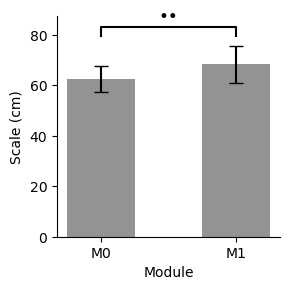

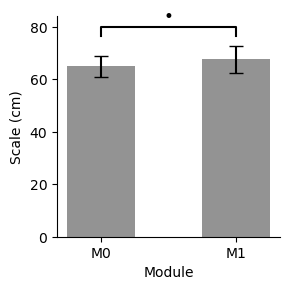

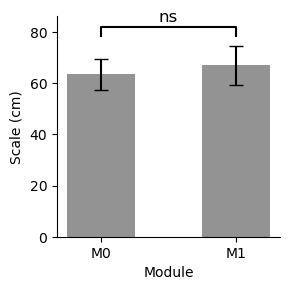

In [21]:
for dt in runs_dt:
    plot_run_module_bars(summary_df, stats_df, dt, dot_mode="levels")

## Single model visualizations

In [112]:
model = 'tpc'
dt = 'Apr-05-2026-21-45-46'
n_cells = 64

run_path = f'../results/{model}/{dt}'
assert os.path.exists(run_path), f'Run path not found: {run_path}'
run_path


'../results/tpc/Apr-05-2026-21-45-46'

In [113]:
module_idx_sorted, cfg = module_index_by_sorted_score(run_path, n_cells=n_cells)

scales_cm, scales_px, scores, unsrt_scores, sacs = get_grid_scales_cm(
    dt=dt, model=model, n_cells=n_cells
)

orientations_deg, axes_deg, _, _, _ = get_grid_orientations_deg(
    dt=dt, model=model, n_cells=n_cells
)

print('Loaded cells:', len(scales_cm))
print('n_module:', cfg.get('n_module', 1), 'module_fracs:', cfg.get('module_fracs', None))


Loaded cells: 64
n_module: 2 module_fracs: [0.7, 0.3]


In [114]:
import numpy as np
import matplotlib.pyplot as plt

def wrap_to_pm30_deg(a_deg):
    return ((np.asarray(a_deg, dtype=float) + 30.0) % 60.0) - 30.0

def _ecdf(x):
    x = np.sort(np.asarray(x, dtype=float))
    y = np.arange(1, x.size + 1) / x.size
    return x, y

def plot_orientation_hist_ecdf_overlay(
    orientations_deg,
    module_idx_sorted,
    modules=(0, 1),
    bins=18,
    xlim=(-30, 30),
    density=True,
):
    ori = np.asarray(orientations_deg, dtype=float)
    mod = np.asarray(module_idx_sorted, dtype=int)

    valid = np.isfinite(ori)
    ori = wrap_to_pm30_deg(ori[valid])
    mod = mod[valid]

    module_colors = {
        0: "#0072B2",  # blue
        1: "#D55E00",  # vermillion
        2: "#009E73",
        3: "#CC79A7",
    }

    fig, (ax_h, ax_e) = plt.subplots(
        2, 1, figsize=(7.2, 6.0), sharex=True,
        gridspec_kw={"height_ratios": [2.0, 1.2], "hspace": 0.08}
    )

    for i, m in enumerate(modules):
        x = ori[mod == m]
        if x.size == 0:
            continue
        color = module_colors.get(int(m), f"C{i}")

        # Histogram overlay
        ax_h.hist(
            x, bins=bins, range=xlim, density=density,
            alpha=0.25, color=color, linewidth=0.8,
            label=f"Module {m} hist (n={x.size})"
        )

        # ECDF overlay
        xe, ye = _ecdf(x)
        ax_e.step(xe, ye, where="post", color=color, lw=2.2, label=f"Module {m} ECDF")

    ax_h.set_ylabel("Density" if density else "Count")
    ax_h.set_title("Orientation Distribution by Module: Histogram + ECDF")
    ax_h.grid(alpha=0.2, linestyle="--")
    ax_h.spines["top"].set_visible(False)
    ax_h.spines["right"].set_visible(False)
    ax_h.legend(frameon=False)

    ax_e.set_xlim(*xlim)
    ax_e.set_ylim(0, 1.02)
    ax_e.set_xlabel("Orientation (deg), wrapped to [-30, 30)")
    ax_e.set_ylabel("ECDF")
    ax_e.grid(alpha=0.2, linestyle="--")
    ax_e.spines["top"].set_visible(False)
    ax_e.spines["right"].set_visible(False)
    ax_e.legend(frameon=False)

    plt.tight_layout()
    plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_13540\1706214842.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


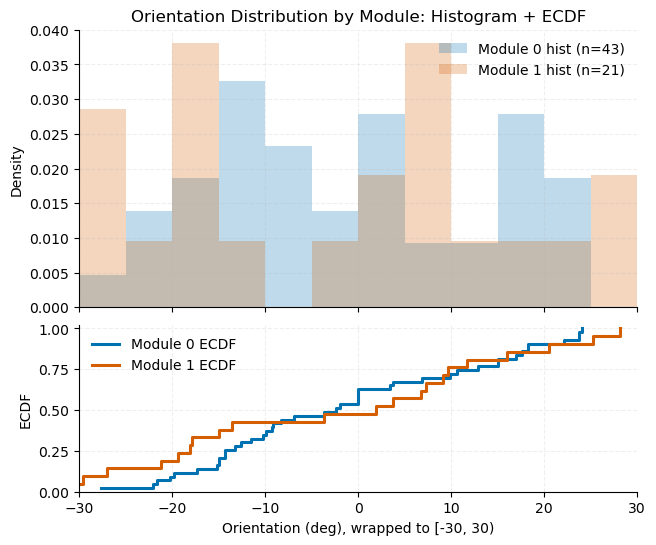

In [117]:
plot_orientation_hist_ecdf_overlay(
    orientations_deg=orientations_deg,
    module_idx_sorted=module_idx_sorted,
    modules=(0, 1),
    bins=12,
)


In [35]:
def plot_run_scales_scatter_hist_kde(
    dt,
    model="tpc",
    n_cells=64,
    k_max=6,
    prominence=0.15,
    grid_size=500,
    bw_mode="exp",
    exp_bw_a=0.5,
    exp_bw_b=0.01,
    exp_bw_min=0.02,
    exp_bw_max=1.0,
):
    import json
    import numpy as np
    import matplotlib.pyplot as plt
    from src.evaluation.module_eval import estimate_k_from_ksd

    path = f"../results/{model}/{dt}"

    # scales/scores in sorted-by-score order
    scales_cm, _, scores, unsrt_scores, _ = get_grid_scales_cm(
        dt, model=model, n_cells=n_cells
    )

    # module ids in sorted-by-score order
    cfg = json.load(open(f"{path}/configs.json", "r"))
    Ng = int(cfg["Ng"])
    n_module = int(cfg.get("n_module", 1))
    fracs = cfg.get("module_fracs", None)

    if fracs is None:
        counts = [Ng // n_module] * n_module
    else:
        fr = np.asarray(fracs, dtype=float)
        fr = fr / fr.sum()
        counts = np.floor(fr * Ng).astype(int)
        counts[-1] = Ng - counts[:-1].sum()
        counts = counts.tolist()

    sort_idx = np.argsort(unsrt_scores)[::-1]
    module_of_orig = np.empty(Ng, dtype=int)
    s = 0
    for m, c in enumerate(counts):
        module_of_orig[s:s+c] = m
        s += c
    module_idx_sorted = module_of_orig[sort_idx][:n_cells]

    # keep valid scales
    valid = np.isfinite(scales_cm) & (scales_cm > 0)
    scales = scales_cm[valid]
    mods = module_idx_sorted[valid]
    scs = scores[:n_cells][valid]

    # NEW: reorder x-axis by module, then by score within module
    order = np.lexsort((-scs, mods))
    scales_o = scales[order]
    mods_o = mods[order]
    x_o = np.arange(len(scales_o))

    # KDE/peaks from log-scales
    k_est, ksd = estimate_k_from_ksd(
        np.log(scales_o),
        k_max=k_max,
        prominence=prominence,
        grid_size=grid_size,
        bw_mode=bw_mode,
        exp_bw_a=exp_bw_a,
        exp_bw_b=exp_bw_b,
        exp_bw_min=exp_bw_min,
        exp_bw_max=exp_bw_max,
    )
    peak_log = ksd["grid"][ksd["peaks"]]
    peak_cm = np.exp(peak_log)

    # plot
    fig = plt.figure(figsize=(6, 4))
    gs = fig.add_gridspec(1, 2, width_ratios=[4, 1.4], wspace=0.05)
    ax_sc = fig.add_subplot(gs[0, 0])
    ax_hi = fig.add_subplot(gs[0, 1], sharey=ax_sc)

    cmap = plt.cm.get_cmap("tab20", max(2, n_module))
    for m in np.unique(mods_o):
        msk = mods_o == m
        ax_sc.scatter(x_o[msk], scales_o[msk], s=16, alpha=0.85, color=cmap(int(m)), label=f"M{int(m)}")

    # module boundaries
    boundaries = np.where(np.diff(mods_o) != 0)[0]
    for b in boundaries:
        ax_sc.axvline(b + 0.5, color="k", ls="--", lw=0.8, alpha=0.5)

    ax_sc.set_xlabel("Cell index")
    ax_sc.set_ylabel("Grid Scale (cm)")
    # ax_sc.set_title(f"{dt} | k_est={k_est}")
    ax_sc.legend(frameon=False, loc="best")
    ax_sc.grid(True, which="major", axis="both", alpha=0.25, linestyle="--")

    # rotated histogram + KDE (on scale axis)
    ax_hi.hist(scales_o, bins=13, orientation="horizontal", density=True, alpha=0.35, color="gray")
    s_grid = np.linspace(scales_o.min(), scales_o.max(), 400)
    dens_s = np.interp(np.log(s_grid), ksd["grid"], ksd["density"]) / s_grid
    ax_hi.plot(dens_s, s_grid, color="black", lw=2)

    peak_dens = ksd["density"][ksd["peaks"]]   # density at each detected peak (log-space KDE)
    for p_cm, d_pk in zip(peak_cm, peak_dens):
        ax_hi.axhline(p_cm, color="crimson", ls="--", lw=1, alpha=0.6)  # optional guide line
        ax_hi.plot(d_pk / p_cm, p_cm, "o", color="crimson", ms=5) 

    ax_hi.set_xlabel("Density")
    plt.setp(ax_hi.get_yticklabels(), visible=False)

    for ax in [ax_sc, ax_hi]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

    return {
        "k_est": k_est,
        "peaks_cm": peak_cm,
        "ordered_scales_cm": scales_o,
        "ordered_modules": mods_o,
        "ksd": ksd,
    }


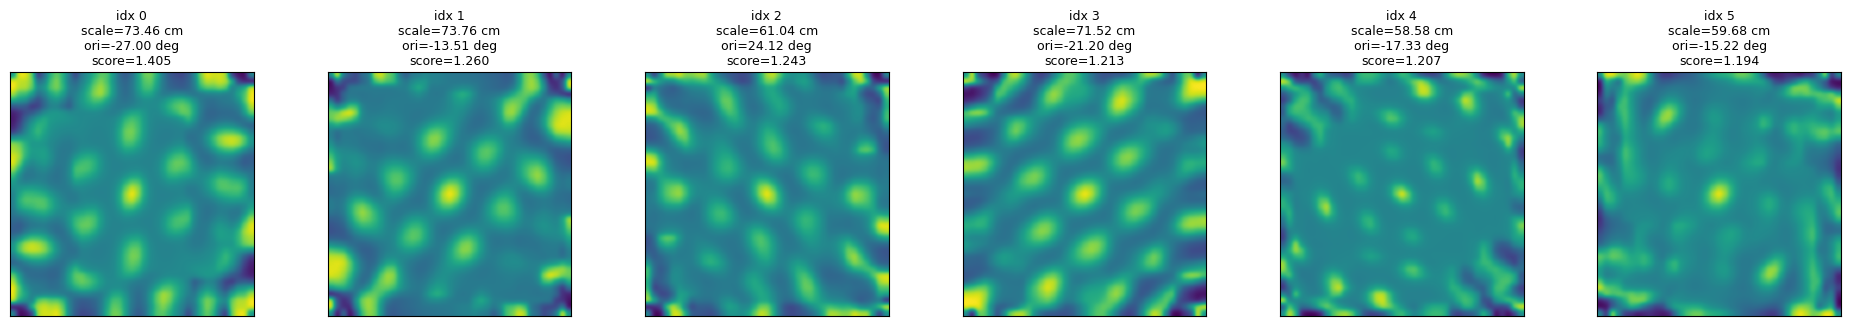

In [37]:
fig, axes = plot_sac_examples_with_scale_orientation(
    sacs=sacs,
    scales_cm=scales_cm,
    orientations_deg=orientations_deg,
    scores=scores,
    n_examples=6,
)


C:\Users\User\AppData\Local\Temp\ipykernel_13540\3017204908.py:82: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab20", max(2, n_module))
C:\Users\User\AppData\Local\Temp\ipykernel_13540\3017204908.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


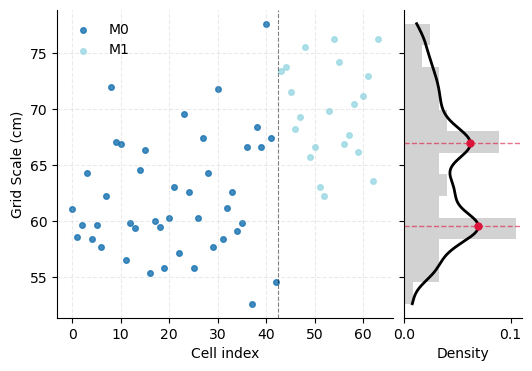

In [36]:
out = plot_run_scales_scatter_hist_kde(
    dt, n_cells=64,
    prominence=0.01,
    grid_size=500,
    bw_mode="exp",
    exp_bw_a=0.4,
    exp_bw_b=0.01,
    exp_bw_min=0.02,
    exp_bw_max=1.0,
)


In [41]:
def plot_run_orientations_scatter_hist_kde(
    dt,
    model="tpc",
    n_cells=64,
    k_max=6,
    prominence=0.15,
    grid_size=500,
    bw_mode="exp",
    exp_bw_a=0.5,
    exp_bw_b=0.01,
    exp_bw_min=0.02,
    exp_bw_max=1.0,
):
    import json
    import numpy as np
    import matplotlib.pyplot as plt
    from src.evaluation.module_eval import (
        estimate_k_from_ksd,
        get_grid_orientations_deg,
    )

    path = f"../results/{model}/{dt}"

    # orientations/scores in sorted-by-score order
    ori_deg, _, scores, unsrt_scores, _ = get_grid_orientations_deg(
        dt, model=model, n_cells=n_cells
    )

    # module ids in sorted-by-score order
    cfg = json.load(open(f"{path}/configs.json", "r"))
    Ng = int(cfg["Ng"])
    n_module = int(cfg.get("n_module", 1))
    fracs = cfg.get("module_fracs", None)

    if fracs is None:
        counts = [Ng // n_module] * n_module
        counts[-1] = Ng - sum(counts[:-1])
    else:
        fr = np.asarray(fracs, dtype=float)
        fr = fr / fr.sum()
        counts = np.floor(fr * Ng).astype(int)
        counts[-1] = Ng - counts[:-1].sum()
        counts = counts.tolist()

    sort_idx = np.argsort(unsrt_scores)[::-1]
    module_of_orig = np.empty(Ng, dtype=int)
    s = 0
    for m, c in enumerate(counts):
        module_of_orig[s:s + c] = m
        s += c
    module_idx_sorted = module_of_orig[sort_idx][:n_cells]

    # keep valid orientations
    valid = np.isfinite(ori_deg)
    ori = ori_deg[valid]
    mods = module_idx_sorted[valid]
    scs = scores[:n_cells][valid]

    # reorder x-axis by module, then by score within module
    order = np.lexsort((-scs, mods))
    ori_o = ori[order]
    mods_o = mods[order]
    x_o = np.arange(len(ori_o))

    # KDE/peaks on orientation values directly
    k_est, ksd = estimate_k_from_ksd(
        ori_o,
        k_max=k_max,
        prominence=prominence,
        grid_size=grid_size,
        bw_mode=bw_mode,
        exp_bw_a=exp_bw_a,
        exp_bw_b=exp_bw_b,
        exp_bw_min=exp_bw_min,
        exp_bw_max=exp_bw_max,
    )
    peak_deg = ksd["grid"][ksd["peaks"]]
    peak_dens = ksd["density"][ksd["peaks"]]

    # plot
    fig = plt.figure(figsize=(6, 4))
    gs = fig.add_gridspec(1, 2, width_ratios=[4, 1.4], wspace=0.05)
    ax_sc = fig.add_subplot(gs[0, 0])
    ax_hi = fig.add_subplot(gs[0, 1], sharey=ax_sc)

    cmap = plt.cm.get_cmap("tab20", max(2, n_module))
    for m in np.unique(mods_o):
        msk = mods_o == m
        ax_sc.scatter(x_o[msk], ori_o[msk], s=16, alpha=0.85, color=cmap(int(m)), label=f"M{int(m)}")

    boundaries = np.where(np.diff(mods_o) != 0)[0]
    for b in boundaries:
        ax_sc.axvline(b + 0.5, color="k", ls="--", lw=0.8, alpha=0.5)

    ax_sc.set_xlabel("Cell index")
    ax_sc.set_ylabel("Grid Orientation (deg)")
    ax_sc.legend(frameon=False, loc="best")
    ax_sc.grid(True, which="major", axis="both", alpha=0.25, linestyle="--")

    # rotated histogram + KDE (on orientation axis)
    ax_hi.hist(ori_o, bins=13, orientation="horizontal", density=True, alpha=0.35, color="gray")
    ax_hi.plot(ksd["density"], ksd["grid"], color="black", lw=2)

    for p_deg, d_pk in zip(peak_deg, peak_dens):
        ax_hi.axhline(p_deg, color="crimson", ls="--", lw=1, alpha=0.6)
        ax_hi.plot(d_pk, p_deg, "o", color="crimson", ms=5)

    ax_hi.set_xlabel("Density")
    plt.setp(ax_hi.get_yticklabels(), visible=False)

    for ax in [ax_sc, ax_hi]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

    return {
        "k_est": k_est,
        "peaks_deg": peak_deg,
        "ordered_orientations_deg": ori_o,
        "ordered_modules": mods_o,
        "ksd": ksd,
    }


C:\Users\User\AppData\Local\Temp\ipykernel_13540\3452569097.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab20", max(2, n_module))
C:\Users\User\AppData\Local\Temp\ipykernel_13540\3452569097.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


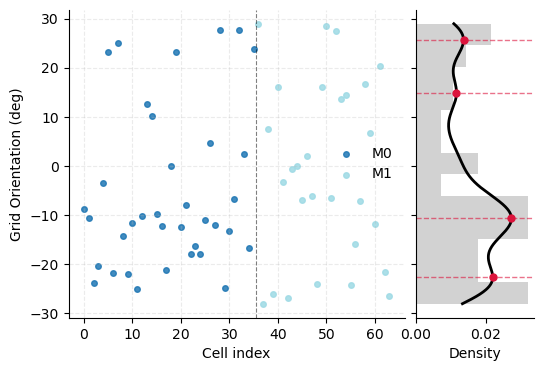

In [119]:
_ = plot_run_orientations_scatter_hist_kde(
    "Apr-05-2026-23-13-47", n_cells=64,
    prominence=0.05,
    grid_size=500,
    bw_mode="exp",
    exp_bw_a=0.4,
    exp_bw_b=0.01,
    exp_bw_min=0.02,
    exp_bw_max=1.0,
)

C:\Users\User\AppData\Local\Temp\ipykernel_15368\2307887597.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab10", max(2, int(cfg.get("n_module", 1))))


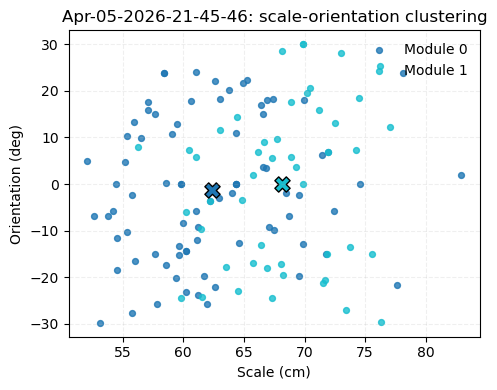

In [33]:
# 2D clustering view: x=scale, y=orientation, colored by module
valid = np.isfinite(scales_cm) & np.isfinite(orientations_deg)
x = scales_cm[valid]
y = orientations_deg[valid]
m = module_idx_sorted[:len(scales_cm)][valid]

plt.figure(figsize=(5, 4))
cmap = plt.cm.get_cmap("tab10", max(2, int(cfg.get("n_module", 1))))

for mod in np.unique(m):
    mk = m == mod
    plt.scatter(x[mk], y[mk], s=18, alpha=0.8, color=cmap(int(mod)), label=f"Module {int(mod)}")

# module centroids
for mod in np.unique(m):
    mk = m == mod
    cx, cy = np.mean(x[mk]), np.mean(y[mk])
    plt.scatter(cx, cy, s=120, marker="X", edgecolor="black", linewidth=1, color=cmap(int(mod)))

plt.xlabel("Scale (cm)")
plt.ylabel("Orientation (deg)")
plt.title(f"{dt}: scale-orientation clustering")
plt.grid(alpha=0.2, linestyle="--")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [147]:
def plot_run_orientations_scatter_hists(
    dt,
    model="tpc",
    n_cells=64,
    bins=13,
):
    import json
    import numpy as np
    import matplotlib.pyplot as plt
    from src.evaluation.module_eval import get_grid_orientations_deg

    path = f"../results/{model}/{dt}"

    # orientations/scores in sorted-by-score order
    ori_deg, _, scores, unsrt_scores, _ = get_grid_orientations_deg(
        dt, model=model, n_cells=n_cells
    )

    # module ids in sorted-by-score order
    cfg = json.load(open(f"{path}/configs.json", "r"))
    Ng = int(cfg["Ng"])
    n_module = int(cfg.get("n_module", 1))
    fracs = cfg.get("module_fracs", None)

    if fracs is None:
        counts = [Ng // n_module] * n_module
        counts[-1] = Ng - sum(counts[:-1])
    else:
        fr = np.asarray(fracs, dtype=float)
        fr = fr / fr.sum()
        counts = np.floor(fr * Ng).astype(int)
        counts[-1] = Ng - counts[:-1].sum()
        counts = counts.tolist()

    sort_idx = np.argsort(unsrt_scores)[::-1]
    module_of_orig = np.empty(Ng, dtype=int)
    s = 0
    for m, c in enumerate(counts):
        module_of_orig[s:s + c] = m
        s += c
    module_idx_sorted = module_of_orig[sort_idx][:n_cells]

    # keep valid orientations
    valid = np.isfinite(ori_deg)
    ori = ori_deg[valid]
    mods = module_idx_sorted[valid]
    scs = scores[:n_cells][valid]

    # reorder x-axis by module, then by score within module
    order = np.lexsort((-scs, mods))
    ori_o = ori[order]
    mods_o = mods[order]
    x_o = np.arange(len(ori_o))

    # colors
    module_colors = {0: "#1F77B4", 1: "#FF7F0E"}

    # layout: scatter + 3 histogram panels (overall, M0, M1)
    fig = plt.figure(figsize=(9, 4))
    gs = fig.add_gridspec(1, 4, width_ratios=[4, 1., 1., 1.], wspace=0.12)

    ax_sc = fig.add_subplot(gs[0, 0])
    ax_all = fig.add_subplot(gs[0, 1], sharey=ax_sc)
    ax_m0 = fig.add_subplot(gs[0, 2], sharey=ax_sc)
    ax_m1 = fig.add_subplot(gs[0, 3], sharey=ax_sc)

    # scatter by module
    for m in np.unique(mods_o):
        m = int(m)
        msk = mods_o == m
        color = module_colors.get(m, f"C{m}")
        ax_sc.scatter(
            x_o[msk], ori_o[msk], s=16, alpha=0.85,
            color=color, label=f"M{m}"
        )

    boundaries = np.where(np.diff(mods_o) != 0)[0]
    for b in boundaries:
        ax_sc.axvline(b + 0.5, color="k", ls="--", lw=0.8, alpha=0.5)

    ax_sc.set_xlabel("Cell index")
    ax_sc.set_ylabel("Grid Orientation (deg)")
    ax_sc.legend(frameon=False, loc="best")
    ax_sc.grid(True, which="major", axis="both", alpha=0.25, linestyle="--")

    # overall histogram
    ax_all.hist(
        ori_o, bins=bins, orientation="horizontal", density=True,
        alpha=0.5, color="gray", edgecolor="white", linewidth=0.8
    )
    ax_all.set_title("Overall", fontsize=10)
    ax_all.set_xlabel("Density")
    plt.setp(ax_all.get_yticklabels(), visible=False)

    # module 0 histogram
    m0 = ori_o[mods_o == 0]
    if len(m0) > 0:
        ax_m0.hist(
            m0, bins=bins, orientation="horizontal", density=True,
            alpha=0.5, color=module_colors[0], edgecolor="white", linewidth=0.8
        )
    ax_m0.set_title(f"Module 0 (n={len(m0)})", fontsize=10)
    ax_m0.set_xlabel("Density")
    plt.setp(ax_m0.get_yticklabels(), visible=False)

    # module 1 histogram
    m1 = ori_o[mods_o == 1]
    if len(m1) > 0:
        ax_m1.hist(
            m1, bins=bins, orientation="horizontal", density=True,
            alpha=0.5, color=module_colors[1], edgecolor="white", linewidth=0.8
        )
    ax_m1.set_title(f"Module 1 (n={len(m1)})", fontsize=10)
    ax_m1.set_xlabel("Density")
    plt.setp(ax_m1.get_yticklabels(), visible=False)

    for ax in [ax_sc, ax_all, ax_m0, ax_m1]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

    return {
        "ordered_orientations_deg": ori_o,
        "ordered_modules": mods_o,
        "module0_orientations": m0,
        "module1_orientations": m1,
    }


C:\Users\User\AppData\Local\Temp\ipykernel_13540\3437276186.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


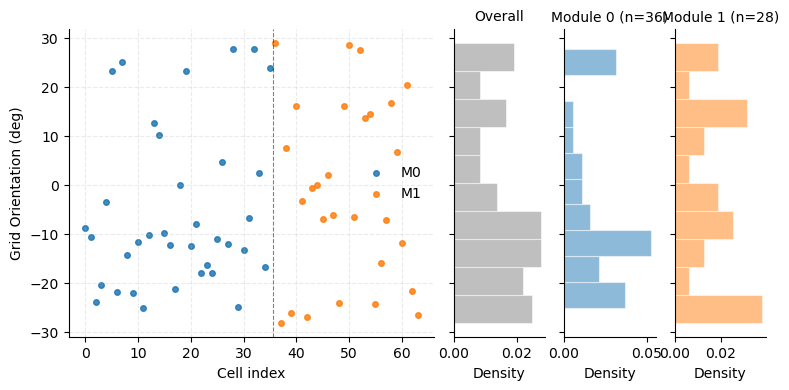

In [148]:
out = plot_run_orientations_scatter_hists(
    dt="Apr-05-2026-23-13-47",
    model="tpc",
    n_cells=64,
    bins=10,
)


In [150]:
def circ_mean_deg_pm30(x):
    th = np.deg2rad(x * 6.0)     # map 60-deg periodicity to full circle
    z = np.exp(1j * th).mean()
    return np.rad2deg(np.angle(z)) / 6.0  # back to [-30,30]

def perm_test_circ_mean_diff(x0, x1, n_perm=10000, seed=0):
    rng = np.random.default_rng(seed)
    obs = abs(circ_mean_deg_pm30(x0) - circ_mean_deg_pm30(x1))

    x = np.concatenate([x0, x1])
    n0 = len(x0)
    cnt = 0
    for _ in range(n_perm):
        rng.shuffle(x)
        d = abs(circ_mean_deg_pm30(x[:n0]) - circ_mean_deg_pm30(x[n0:]))
        cnt += (d >= obs)
    p = (cnt + 1) / (n_perm + 1)
    return obs, p

obs, p_perm = perm_test_circ_mean_diff(x0, x1)
print(f"Permutation |Δ circular mean| = {obs:.3f} deg, p-value = {p_perm:.3e}")


Permutation |Δ circular mean| = 31.086 deg, p-value = 1.820e-02
